## modèle de prédiction de démission

In [500]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix
)

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance


import warnings
warnings.filterwarnings("ignore")
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import plotly.express as px
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer


# Modèles linéaires
from sklearn.linear_model import LogisticRegression

# Arbres de décision
from sklearn.tree import DecisionTreeClassifier

# Ensembles d'arbres
from sklearn.ensemble import (
    RandomForestClassifier,
    ExtraTreesClassifier,
    GradientBoostingClassifier,
    AdaBoostClassifier,
    HistGradientBoostingClassifier
)

# Modèles basés sur distance
from sklearn.neighbors import KNeighborsClassifier

# Support Vector Machines
from sklearn.svm import SVC

# Modèle probabiliste
from sklearn.naive_bayes import GaussianNB
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline


## Chargement du dataset

In [501]:
DATA_PATH = "HRDataset_v14.csv"

df = pd.read_csv(DATA_PATH)
df.head()

,Employee_Name,EmpID,MarriedID,MaritalStatusID,GenderID,EmpStatusID,DeptID,PerfScoreID,FromDiversityJobFairID,Salary,...,ManagerName,ManagerID,RecruitmentSource,PerformanceScore,EngagementSurvey,EmpSatisfaction,SpecialProjectsCount,LastPerformanceReview_Date,DaysLateLast30,Absences
0,"Adinolfi, Wilson K",10026,0,0,1,1,5,4,0,62506,...,Michael Albert,22.0,LinkedIn,Exceeds,4.60,5,0,1/17/2019,0,1
1,"Ait Sidi, Karthikeyan",10084,1,1,1,5,3,3,0,104437,...,Simon Roup,4.0,Indeed,Fully Meets,4.96,3,6,2/24/2016,0,17
2,"Akinkuolie, Sarah",10196,1,1,0,5,5,3,0,64955,...,Kissy Sullivan,20.0,LinkedIn,Fully Meets,3.02,3,0,5/15/2012,0,3
3,"Alagbe,Trina",10088,1,1,0,1,5,3,0,64991,...,Elijiah Gray,16.0,Indeed,Fully Meets,4.84,5,0,1/3/2019,0,15
4,"Anderson, Carol",10069,0,2,0,5,5,3,0,50825,...,Webster Butler,39.0,Google Search,Fully Meets,5.00,4,0,2/1/2016,0,2


## Structure des données

In [502]:
print("Shape du dataset :", df.shape)
print("\nColonnes :")
print(df.columns.tolist())

Shape du dataset : (311, 36)

Colonnes :
['Employee_Name', 'EmpID', 'MarriedID', 'MaritalStatusID', 'GenderID', 'EmpStatusID', 'DeptID', 'PerfScoreID', 'FromDiversityJobFairID', 'Salary', 'Termd', 'PositionID', 'Position', 'State', 'Zip', 'DOB', 'Sex', 'MaritalDesc', 'CitizenDesc', 'HispanicLatino', 'RaceDesc', 'DateofHire', 'DateofTermination', 'TermReason', 'EmploymentStatus', 'Department', 'ManagerName', 'ManagerID', 'RecruitmentSource', 'PerformanceScore', 'EngagementSurvey', 'EmpSatisfaction', 'SpecialProjectsCount', 'LastPerformanceReview_Date', 'DaysLateLast30', 'Absences']


## Nettoyage léger des colonnes texte

In [503]:
for col in df.select_dtypes(include="object").columns:
    df[col] = df[col].astype(str).str.strip()

## Exploration des données

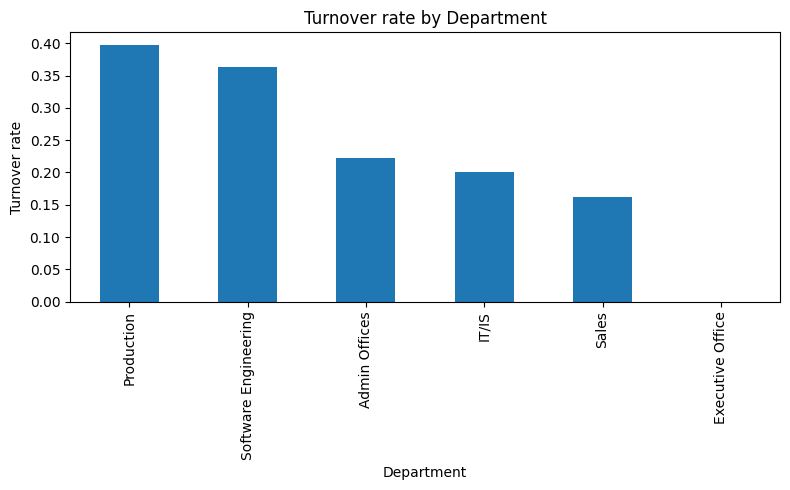

In [504]:
turnover_by_dept = df.groupby("Department")["Termd"].mean().sort_values(ascending=False)

plt.figure(figsize=(8,5))
turnover_by_dept.plot(kind="bar")

plt.title("Turnover rate by Department")
plt.ylabel("Turnover rate")
plt.xlabel("Department")

plt.tight_layout()
plt.show()

<Figure size 700x500 with 0 Axes>

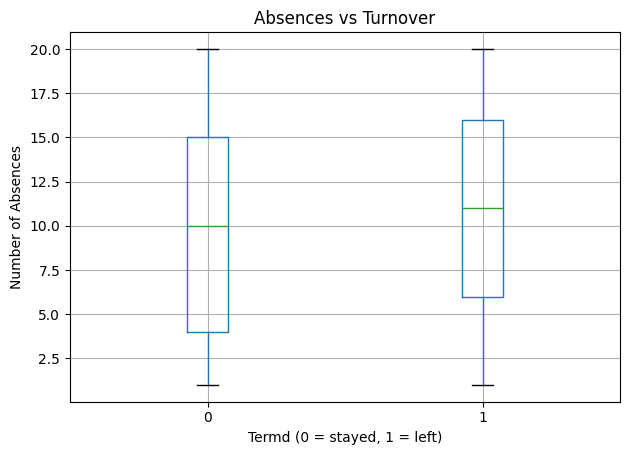

In [505]:
plt.figure(figsize=(7,5))

df.boxplot(column="Absences", by="Termd")

plt.title("Absences vs Turnover")
plt.suptitle("")
plt.xlabel("Termd (0 = stayed, 1 = left)")
plt.ylabel("Number of Absences")

plt.tight_layout()
plt.show()

<Figure size 700x500 with 0 Axes>

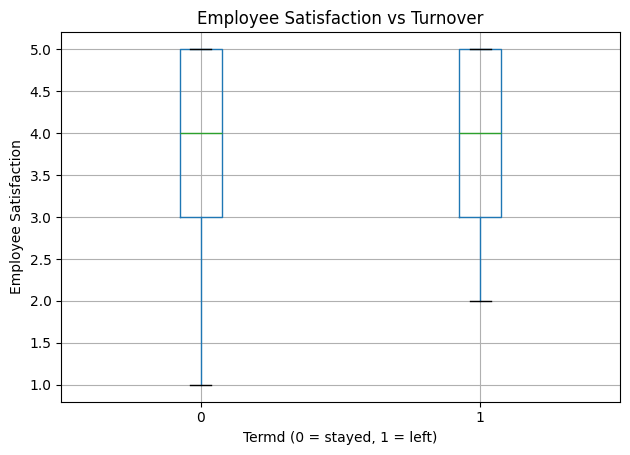

In [506]:
plt.figure(figsize=(7,5))

df.boxplot(column="EmpSatisfaction", by="Termd")

plt.title("Employee Satisfaction vs Turnover")
plt.suptitle("")
plt.xlabel("Termd (0 = stayed, 1 = left)")
plt.ylabel("Employee Satisfaction")

plt.tight_layout()
plt.show()

In [507]:


# On garde uniquement les variables numériques
num_df = df.select_dtypes(include=["int64", "float64"])

# Calcul de la corrélation
corr_matrix = num_df.corr()

# Création de la heatmap interactive
fig = px.imshow(
    corr_matrix,
    text_auto=True,
    color_continuous_scale="Viridis",
    title="Interactive Correlation Matrix"
)

fig.update_layout(
    width=900,
    height=800
)

fig.show()

In [508]:
import plotly.express as px

# calcul de la corrélation
corr_matrix = df.corr(numeric_only=True)

# corrélation avec la cible
corr_with_target = corr_matrix["Termd"].drop("Termd")

# tri par importance
corr_sorted = corr_with_target.sort_values(key=abs, ascending=False)

# on prend les 10 plus corrélées
top_features = corr_sorted.head(10)

fig = px.bar(
    x=top_features.values,
    y=top_features.index,
    orientation='h',
    title="Top Features Correlated with Employee Turnover (Termd)",
    labels={"x": "Correlation", "y": "Feature"},
    color=top_features.values,
    color_continuous_scale="Viridis"
)

fig.update_layout(height=500)

fig.show()

### Interpretation

This correlation analysis highlights the variables most associated with employee turnover (`Termd`).

As expected, **EmpStatusID shows an extremely high correlation (~0.95)** with the target variable because it directly encodes the employee's employment status. This represents a **data leakage risk**, since it contains information that would not be available when predicting future turnover. Therefore, this variable must be removed from the modeling dataset.

Other variables such as **ManagerID, DaysLateLast30, Absences, and PositionID** show weaker but potentially meaningful correlations with turnover. These features may capture behavioral or organizational patterns related to employee disengagement or workplace conditions.

Conversely, variables with very low correlation with the target (e.g., **Salary, SpecialProjectsCount, Zip**) may contribute less predictive information and can be candidates for removal or further feature engineering.

This analysis helps guide **feature selection**, improving model robustness while reducing noise and maintaining interpretability.

## Variables à supprimer

In [509]:
cols_to_remove = [
    "EmpID",                # identifiant
    "Employee_Name",        # identifiant
    "Zip",                  # localisation brute
    "ManagerID",            # identifiant
    "EmpStatusID",          # directement lié à Termd
    "DateofTermination",    # fuite d'information
    "TermReason",           # fuite d'information
    "EmploymentStatus",
    'PositionID',
    "MarriedID",            # doublon technique de MaritalDesc
    "MaritalStatusID",      # doublon technique          
    "DeptID",               # doublon de Department
    "PositionID",           # doublon de Position
    "PerfScoreID",          # doublon de PerformanceScore
    "ManagerName",          # trop de catégories / non généralisable
    "State", 
    "GenderID",               # peu utile pour ce dataset
    "FromDiversityJobFairID", # variable administrative
        # redondant avec RaceDesc
 
 
]

### Feature Selection and Data Cleaning

To improve model robustness and avoid data leakage, several columns were removed from the dataset before training the models.

First, **identifiers and administrative variables** such as `EmpID`, `Employee_Name`, and `ManagerID` were removed because they do not provide meaningful predictive information and could introduce noise into the model.

Second, variables that **directly leak information about the target variable (`Termd`)** were excluded, such as `EmpStatusID`, `DateofTermination`, `TermReason`, and `EmploymentStatus`. Including these variables would artificially inflate model performance because they encode information that would not be available when predicting future employee turnover.

Third, several **technical ID columns** (`MarriedID`, `MaritalStatusID`, `DeptID`, `PositionID`, `PerfScoreID`, `GenderID`) were removed because they duplicate information already contained in more interpretable categorical variables (e.g., `MaritalDesc`, `Department`, `Position`, `PerformanceScore`, `Sex`).

Finally, some **high-cardinality or administrative variables** such as `ManagerName`, `State`, and `FromDiversityJobFairID` were excluded as they add complexity without improving predictive value.

This cleaning step helps create a dataset that is **more interpretable, less noisy, and better suited for building reliable machine learning models**.

In [510]:
df_model = df.drop(columns=cols_to_remove, errors="ignore")

In [511]:
df_model.columns

Index(['Salary', 'Termd', 'Position', 'DOB', 'Sex', 'MaritalDesc',
       'CitizenDesc', 'HispanicLatino', 'RaceDesc', 'DateofHire', 'Department',
       'RecruitmentSource', 'PerformanceScore', 'EngagementSurvey',
       'EmpSatisfaction', 'SpecialProjectsCount', 'LastPerformanceReview_Date',
       'DaysLateLast30', 'Absences'],
      dtype='object')

In [512]:
df_fe = df_model.copy()
df_fe.columns

Index(['Salary', 'Termd', 'Position', 'DOB', 'Sex', 'MaritalDesc',
       'CitizenDesc', 'HispanicLatino', 'RaceDesc', 'DateofHire', 'Department',
       'RecruitmentSource', 'PerformanceScore', 'EngagementSurvey',
       'EmpSatisfaction', 'SpecialProjectsCount', 'LastPerformanceReview_Date',
       'DaysLateLast30', 'Absences'],
      dtype='object')

In [513]:
# =========================================================
# FEATURE ENGINEERING RH
# =========================================================

df_fe = df_model.copy()

# -----------------------------
# 1. Conversion des dates
# -----------------------------
date_cols = ["DOB", "DateofHire", "LastPerformanceReview_Date"]

for col in date_cols:
    if col in df_fe.columns:
        df_fe[col] = pd.to_datetime(df_fe[col], errors="coerce")

today = pd.Timestamp.today().normalize()

# -----------------------------
# 2. Age
# -----------------------------
if "DOB" in df_fe.columns:
    df_fe["Age"] = ((today - df_fe["DOB"]).dt.days / 365.25).round(1)

# -----------------------------
# 3. Ancienneté
# -----------------------------
if "DateofHire" in df_fe.columns:
    df_fe["TenureYears"] = ((today - df_fe["DateofHire"]).dt.days / 365.25).round(2)

# -----------------------------
# 4. Temps depuis la dernière review
# -----------------------------
#if "LastPerformanceReview_Date" in df_fe.columns:
   # df_fe["YearsSinceReview"] = (
   #     (today - df_fe["LastPerformanceReview_Date"]).dt.days / 365.25
   # ).round(2)

# -----------------------------
# 5. Score combiné engagement / satisfaction
# -----------------------------
if {"EngagementSurvey", "EmpSatisfaction"}.issubset(df_fe.columns):
    df_fe["EngagementCombined"] = (
        df_fe["EngagementSurvey"] + df_fe["EmpSatisfaction"]
    ) / 2

# -----------------------------
# 6. Score comportemental simple
# -----------------------------
if {"Absences", "DaysLateLast30"}.issubset(df_fe.columns):
    df_fe["BehaviorRiskScore"] = df_fe["Absences"] + df_fe["DaysLateLast30"]

# -----------------------------
# 7. Interaction absences x insatisfaction
# Plus la satisfaction est basse, plus l'effet des absences peut être fort
# -----------------------------
if {"Absences", "EmpSatisfaction"}.issubset(df_fe.columns):
    df_fe["AbsenceSatisfactionInteraction"] = (
        df_fe["Absences"] * (5 - df_fe["EmpSatisfaction"])
    )

# -----------------------------
# 8. Ratios liés à l'ancienneté
# -----------------------------
if {"Absences", "TenureYears"}.issubset(df_fe.columns):
    df_fe["AbsencesPerYear"] = df_fe["Absences"] / (df_fe["TenureYears"] + 1)

if {"SpecialProjectsCount", "TenureYears"}.issubset(df_fe.columns):
    df_fe["ProjectsPerYear"] = df_fe["SpecialProjectsCount"] / (df_fe["TenureYears"] + 1)

# -----------------------------
# 9. Tranches de salaire
# -----------------------------
if "Salary" in df_fe.columns:
    df_fe["SalaryBand"] = pd.qcut(
        df_fe["Salary"],
        q=4,
        labels=["Low", "Mid-Low", "Mid-High", "High"],
        duplicates="drop"
    )

# -----------------------------
# 10. Tranches d'ancienneté
# -----------------------------
if "TenureYears" in df_fe.columns:
    df_fe["TenureBand"] = pd.cut(
        df_fe["TenureYears"],
        bins=[-1, 1, 3, 7, 100],
        labels=["<1y", "1-3y", "3-7y", "7y+"]
    )

# -----------------------------
# 11. Tranches d'âge
# Facultatif : à documenter car variable sensible potentielle
# -----------------------------
if "Age" in df_fe.columns:
    df_fe["AgeBand"] = pd.cut(
        df_fe["Age"],
        bins=[0, 25, 35, 45, 55, 100],
        labels=["<=25", "26-35", "36-45", "46-55", "55+"]
    )

# -----------------------------
# 12. Nettoyage : on retire les dates brutes
# -----------------------------
cols_to_drop_after_fe = [
    "DOB",
    "DateofHire",
    "LastPerformanceReview_Date"
]

df_fe = df_fe.drop(columns=cols_to_drop_after_fe, errors="ignore")

df_fe.head()
df

,Employee_Name,EmpID,MarriedID,MaritalStatusID,GenderID,EmpStatusID,DeptID,PerfScoreID,FromDiversityJobFairID,Salary,...,ManagerName,ManagerID,RecruitmentSource,PerformanceScore,EngagementSurvey,EmpSatisfaction,SpecialProjectsCount,LastPerformanceReview_Date,DaysLateLast30,Absences
0,"Adinolfi, Wilson K",10026,0,0,1,1,5,4,0,62506,...,Michael Albert,22.0,LinkedIn,Exceeds,4.60,5,0,1/17/2019,0,1
1,"Ait Sidi, Karthikeyan",10084,1,1,1,5,3,3,0,104437,...,Simon Roup,4.0,Indeed,Fully Meets,4.96,3,6,2/24/2016,0,17
2,"Akinkuolie, Sarah",10196,1,1,0,5,5,3,0,64955,...,Kissy Sullivan,20.0,LinkedIn,Fully Meets,3.02,3,0,5/15/2012,0,3
3,"Alagbe,Trina",10088,1,1,0,1,5,3,0,64991,...,Elijiah Gray,16.0,Indeed,Fully Meets,4.84,5,0,1/3/2019,0,15
4,"Anderson, Carol",10069,0,2,0,5,5,3,0,50825,...,Webster Butler,39.0,Google Search,Fully Meets,5.00,4,0,2/1/2016,0,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
306,"Woodson, Jason",10135,0,0,1,1,5,3,0,65893,...,Kissy Sullivan,20.0,LinkedIn,Fully Meets,4.07,4,0,2/28/2019,0,13
307,"Ybarra, Catherine",10301,0,0,0,5,5,1,0,48513,...,Brannon Miller,12.0,Google Search,PIP,3.20,2,0,9/2/2015,5,4
308,"Zamora, Jennifer",10010,0,0,0,1,3,4,0,220450,...,Janet King,2.0,Employee Referral,Exceeds,4.60,5,6,2/21/2019,0,16
309,"Zhou, Julia",10043,0,0,0,1,3,3,0,89292,...,Simon Roup,4.0,Employee Referral,Fully Meets,5.00,3,5,2/1/2019,0,11


In [514]:
df_fe.columns

Index(['Salary', 'Termd', 'Position', 'Sex', 'MaritalDesc', 'CitizenDesc',
       'HispanicLatino', 'RaceDesc', 'Department', 'RecruitmentSource',
       'PerformanceScore', 'EngagementSurvey', 'EmpSatisfaction',
       'SpecialProjectsCount', 'DaysLateLast30', 'Absences', 'Age',
       'TenureYears', 'EngagementCombined', 'BehaviorRiskScore',
       'AbsenceSatisfactionInteraction', 'AbsencesPerYear', 'ProjectsPerYear',
       'SalaryBand', 'TenureBand', 'AgeBand'],
      dtype='object')

In [515]:
sensitive_features = ["Sex", "RaceDesc","HispanicLatino"]

audit_df = df_model[sensitive_features]

X = df_fe.drop(columns=sensitive_features, errors="ignore")

y = df_fe["Termd"]

X.drop(["Termd"], axis=1, inplace=True, errors="ignore")


X.columns

Index(['Salary', 'Position', 'MaritalDesc', 'CitizenDesc', 'Department',
       'RecruitmentSource', 'PerformanceScore', 'EngagementSurvey',
       'EmpSatisfaction', 'SpecialProjectsCount', 'DaysLateLast30', 'Absences',
       'Age', 'TenureYears', 'EngagementCombined', 'BehaviorRiskScore',
       'AbsenceSatisfactionInteraction', 'AbsencesPerYear', 'ProjectsPerYear',
       'SalaryBand', 'TenureBand', 'AgeBand'],
      dtype='object')

In [516]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test, audit_train, audit_test = train_test_split(
    X,
    y,
    audit_df,
    test_size=0.25,
    random_state=42,
    stratify=y
)

In [517]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test, audit_train, audit_test = train_test_split(
    X,
    y,
    audit_df,
    test_size=0.25,
    random_state=42,
    stratify=y
)




In [518]:
numeric_features = X_train.select_dtypes(include=["int64","float64"]).columns.tolist()

categorical_features = X_train.select_dtypes(exclude=["int64","float64"]).columns.tolist()

print("Numerical:", numeric_features)
print("Categorical:", categorical_features)

Numerical: ['Salary', 'EngagementSurvey', 'EmpSatisfaction', 'SpecialProjectsCount', 'DaysLateLast30', 'Absences', 'Age', 'TenureYears', 'EngagementCombined', 'BehaviorRiskScore', 'AbsenceSatisfactionInteraction', 'AbsencesPerYear', 'ProjectsPerYear']
Categorical: ['Position', 'MaritalDesc', 'CitizenDesc', 'Department', 'RecruitmentSource', 'PerformanceScore', 'SalaryBand', 'TenureBand', 'AgeBand']


In [519]:


numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

preprocessor = ColumnTransformer([
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features)
])

In [520]:


models = {
    "LogisticRegression": LogisticRegression(
        max_iter=3000,
        class_weight="balanced",
        random_state=42
    ),

    "DecisionTree": DecisionTreeClassifier(
        max_depth=5,
        min_samples_leaf=10,
        class_weight="balanced",
        random_state=42
    ),

    "RandomForest": RandomForestClassifier(
        n_estimators=300,
        max_depth=8,
        min_samples_leaf=5,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    ),

    "ExtraTrees": ExtraTreesClassifier(
        n_estimators=300,
        max_depth=8,
        min_samples_leaf=5,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    ),

    "GradientBoosting": GradientBoostingClassifier(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=3,
        random_state=42
    ),

    "AdaBoost": AdaBoostClassifier(
        n_estimators=200,
        learning_rate=0.05,
        random_state=42
    ),

    "HistGradientBoosting": HistGradientBoostingClassifier(
        max_depth=6,
        learning_rate=0.05,
        max_iter=200,
        random_state=42
    ),

    "KNN": KNeighborsClassifier(
        n_neighbors=7,
        weights="distance"
    ),

    "SVM": SVC(
        probability=True,
        class_weight="balanced",
        kernel="rbf",
        C=1.0,
        gamma="scale",
        random_state=42
    ),

    "GaussianNB": GaussianNB()
}

In [521]:
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

results = []
pipelines = {}

for name, model in models.items():
    print(f"Training {name}...")

    pipeline = ImbPipeline([
        ("preprocessor", preprocessor),
        ("smote", SMOTE(random_state=42, k_neighbors=3)),
        ("model", model)
    ])

    pipeline.fit(X_train, y_train)

    y_pred = pipeline.predict(X_test)

    if hasattr(pipeline, "predict_proba"):
        y_prob = pipeline.predict_proba(X_test)[:, 1]
        roc_auc = roc_auc_score(y_test, y_prob)
    else:
        y_prob = None
        roc_auc = None

    results.append({
        "model": name,
        "accuracy": accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred, zero_division=0),
        "recall": recall_score(y_test, y_pred, zero_division=0),
        "f1": f1_score(y_test, y_pred, zero_division=0),
        "roc_auc": roc_auc
    })

    pipelines[name] = pipeline

print("All models trained.")

Training LogisticRegression...
Training DecisionTree...
Training RandomForest...
Training ExtraTrees...
Training GradientBoosting...
Training AdaBoost...
Training HistGradientBoosting...
Training KNN...
Training SVM...
Training GaussianNB...
All models trained.


In [522]:
results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    by=["roc_auc", "f1", "accuracy"],
    ascending=False
)

results_df.round(4)


,model,accuracy,precision,recall,f1,roc_auc
2,RandomForest,0.7564,0.6061,0.7692,0.6780,0.8180
8,SVM,0.7051,0.5405,0.7692,0.6349,0.8166
6,HistGradientBoosting,0.7179,0.5714,0.6154,0.5926,0.8040
5,AdaBoost,0.7564,0.6207,0.6923,0.6545,0.7785
3,ExtraTrees,0.6923,0.5294,0.6923,0.6000,0.7722
4,GradientBoosting,0.7308,0.6000,0.5769,0.5882,0.7655
7,KNN,0.7308,0.6316,0.4615,0.5333,0.7633
0,LogisticRegression,0.7051,0.5429,0.7308,0.6230,0.7544
1,DecisionTree,0.7051,0.5385,0.8077,0.6462,0.7371
9,GaussianNB,0.3974,0.3385,0.8462,0.4835,0.5096


In [523]:
best_model_name = results_df.iloc[0]["model"]

best_model = pipelines[best_model_name]

In [524]:
from sklearn.inspection import permutation_importance

perm = permutation_importance(
    best_model,
    X_test,
    y_test,
    n_repeats=10,
    random_state=42,
    scoring="f1"
)

importance_df = pd.DataFrame({
    "feature": X_test.columns,
    "importance": perm.importances_mean
}).sort_values("importance", ascending=False)

importance_df.head(10)
df_fe.columns

Index(['Salary', 'Termd', 'Position', 'Sex', 'MaritalDesc', 'CitizenDesc',
       'HispanicLatino', 'RaceDesc', 'Department', 'RecruitmentSource',
       'PerformanceScore', 'EngagementSurvey', 'EmpSatisfaction',
       'SpecialProjectsCount', 'DaysLateLast30', 'Absences', 'Age',
       'TenureYears', 'EngagementCombined', 'BehaviorRiskScore',
       'AbsenceSatisfactionInteraction', 'AbsencesPerYear', 'ProjectsPerYear',
       'SalaryBand', 'TenureBand', 'AgeBand'],
      dtype='object')

In [ ]:
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE

param_spaces = {
    "LogisticRegression": {
        "model__C": [0.01, 0.1, 1.0, 5.0, 10.0],
        "model__solver": ["lbfgs", "liblinear"]
    },
    "DecisionTree": {
        "model__max_depth": [3, 5, 7, 10, None],
        "model__min_samples_leaf": [1, 2, 5, 10, 20],
        "model__min_samples_split": [2, 5, 10, 20]
    },
    "RandomForest": {
        "model__n_estimators": [100, 200, 300, 500],
        "model__max_depth": [5, 8, 12, None],
        "model__min_samples_leaf": [1, 2, 5, 10],
        "model__max_features": ["sqrt", "log2", None]
    },
    "ExtraTrees": {
        "model__n_estimators": [100, 200, 300, 500],
        "model__max_depth": [5, 8, 12, None],
        "model__min_samples_leaf": [1, 2, 5, 10],
        "model__max_features": ["sqrt", "log2", None]
    },
    "GradientBoosting": {
        "model__n_estimators": [100, 200, 300],
        "model__learning_rate": [0.01, 0.03, 0.05, 0.1],
        "model__max_depth": [2, 3, 4, 5],
        "model__subsample": [0.7, 0.85, 1.0]
    },
    "AdaBoost": {
        "model__n_estimators": [50, 100, 200, 300],
        "model__learning_rate": [0.01, 0.05, 0.1, 0.5, 1.0]
    },
    "HistGradientBoosting": {
        "model__max_depth": [None, 3, 5, 7],
        "model__learning_rate": [0.01, 0.03, 0.05, 0.1],
        "model__max_iter": [100, 200, 300],
        "model__min_samples_leaf": [10, 20, 30]
    },
    "KNN": {
        "model__n_neighbors": [3, 5, 7, 9, 11, 15],
        "model__weights": ["uniform", "distance"],
        "model__p": [1, 2]
    },
    "SVM": {
        "model__C": [0.1, 1.0, 5.0, 10.0, 50.0],
        "model__gamma": ["scale", "auto", 0.01, 0.1, 1.0],
        "model__kernel": ["rbf", "linear"]
    },
    "GaussianNB": {
        "model__var_smoothing": [1e-12, 1e-11, 1e-10, 1e-9, 1e-8]
    }
}

optimized_results = []
optimized_pipelines = {}
optimized_searches = {}

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

for name, model in models.items():
    print(f"Optimizing {name}...")

    pipeline = ImbPipeline([
        ("preprocessor", preprocessor),
        ("smote", SMOTE(random_state=42, k_neighbors=3)),
        ("model", model)
    ])

    search = RandomizedSearchCV(
        estimator=pipeline,
        param_distributions=param_spaces[name],
        n_iter=10,
        scoring="f1",
        cv=cv,
        n_jobs=-1,
        random_state=42,
        refit=True
    )

    search.fit(X_train, y_train)
    best_pipeline = search.best_estimator_

    y_pred = best_pipeline.predict(X_test)

    if hasattr(best_pipeline, "predict_proba"):
        y_prob = best_pipeline.predict_proba(X_test)[:, 1]
        roc_auc = roc_auc_score(y_test, y_prob)
    else:
        roc_auc = None

    optimized_results.append({
        "model": name,
        "accuracy": accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred, zero_division=0),
        "recall": recall_score(y_test, y_pred, zero_division=0),
        "f1": f1_score(y_test, y_pred, zero_division=0),
        "roc_auc": roc_auc,
        "best_params": search.best_params_
    })

    optimized_pipelines[name] = best_pipeline
    optimized_searches[name] = search

print("All optimized models trained.")

optimized_results_df = pd.DataFrame(optimized_results).sort_values(
    by=["roc_auc", "f1", "accuracy"],
    ascending=False
)

optimized_results_df.round(4)



In [ ]:
# SAVE_BEST_MODEL_ARTIFACTS
import json
from pathlib import Path
import joblib
import pandas as pd

artifact_dir = Path("predictive_model/artifacts")
artifact_dir.mkdir(parents=True, exist_ok=True)

if "optimized_results_df" in globals() and "optimized_pipelines" in globals():
    selected_df = optimized_results_df
    selected_pipelines = optimized_pipelines
else:
    selected_df = results_df
    selected_pipelines = pipelines

best_model_name_saved = selected_df.iloc[0]["model"]
best_model_saved = selected_pipelines[best_model_name_saved]

feature_columns = list(X.columns)
numeric_features_saved = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features_saved = [c for c in feature_columns if c not in numeric_features_saved]

defaults = {}
baseline = {}
for col in feature_columns:
    if col in numeric_features_saved:
        defaults[col] = float(X[col].median())
        baseline[col] = float(X_train[col].median())
    else:
        mode_all = X[col].mode(dropna=True)
        mode_train = X_train[col].mode(dropna=True)
        defaults[col] = str(mode_all.iloc[0]) if not mode_all.empty else ""
        baseline[col] = str(mode_train.iloc[0]) if not mode_train.empty else ""

metadata = {
    "best_model": best_model_name_saved,
    "metrics": selected_df.to_dict(orient="records"),
    "feature_columns": feature_columns,
    "numeric_features": numeric_features_saved,
    "categorical_features": categorical_features_saved,
    "defaults": defaults,
    "baseline": baseline,
    "explainable_features": [
        "Absences",
        "EmpSatisfaction",
        "EngagementSurvey",
        "Salary",
        "DaysLateLast30",
        "SpecialProjectsCount",
        "PerformanceScore",
        "Department",
        "Position",
        "RecruitmentSource"
    ]
}

joblib.dump(best_model_saved, artifact_dir / "best_model.joblib")
(artifact_dir / "best_model_meta.json").write_text(
    json.dumps(metadata, ensure_ascii=False, indent=2),
    encoding="utf-8"
)
print(f"Saved model: {best_model_name_saved}")
print(f"Artifacts folder: {artifact_dir.resolve()}")

